# Combined Temperature and Load Analytics
## Correlation Analysis Between City Temperatures and Energy Loads

This notebook analyzes the relationship between temperature patterns and electricity load demand across multiple US cities:
- **Load Cities**: Boston, New York, Chicago, Minneapolis
- **Temperature Cities**: Boston, New York, Chicago, Minneapolis, Houston, Dallas

**Data Source**: Pre-processed pickle files from Temperature_Analytics2.ipynb and Load_Analytics.ipynb

## 1. Setup and Data Loading

In [118]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import pickle
import warnings
warnings.filterwarnings('ignore')

from wxderivs import SET_TARGET_US_CITIES, MONTH_CDD, MONTH_HDD, DIR_WORK

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [119]:
# Load temperature data
with open('../data/processed/temperature_analysis_data.pkl', 'rb') as f:
    temp_data = pickle.load(f)

# Load load data
with open('../data/processed/all_analysis_data.pkl', 'rb') as f:
    load_data = pickle.load(f)

print("Temperature Data Keys:", list(temp_data.keys()))
print("\nLoad Data Keys:", list(load_data.keys()))

Temperature Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_houston', 'df_dallas', 'df_res', 'df_cdd_temp_res', 'df_hdd_temp_res', 'df_result', 'region_fit', 'df_tdc_temp_cdd_res', 'df_tdc_temp_hdd_res', 'dct_evi_temp_res_right', 'dct_evi_temp_res_left', 'df_evi_res_right', 'df_evi_res_left', 'boston_garch_fit', 'summary_stats', 'volatility_by_doy']

Load Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_res', 'df_cdd_load_res', 'df_hdd_load_res', 'df_result', 'df_tdc_load_cdd_res', 'df_tdc_load_hdd_res', 'dct_evi_load_res_right', 'dct_evi_load_res_left', 'df_evi_res_right', 'df_evi_res_left']


In [120]:
# Extract temperature dataframes
temp_boston = temp_data['df_boston'].copy()
temp_ny = temp_data['df_ny'].copy()
temp_chicago = temp_data['df_chicago'].copy()
temp_minneapolis = temp_data['df_minneapolis'].copy()
temp_houston = temp_data['df_houston'].copy()
temp_dallas = temp_data['df_dallas'].copy()

# Extract load dataframes
load_boston = load_data['df_boston'].copy()
load_ny = load_data['df_ny'].copy()
load_chicago = load_data['df_chicago'].copy()
load_minneapolis = load_data['df_minneapolis'].copy()

print("Temperature DataFrames:")
print(f"  Boston: {temp_boston.shape}")
print(f"  New York: {temp_ny.shape}")
print(f"  Chicago: {temp_chicago.shape}")
print(f"  Minneapolis: {temp_minneapolis.shape}")
print(f"  Houston: {temp_houston.shape}")
print(f"  Dallas: {temp_dallas.shape}")

print("\nLoad DataFrames:")
print(f"  Boston: {load_boston.shape}")
print(f"  New York: {load_ny.shape}")
print(f"  Chicago: {load_chicago.shape}")
print(f"  Minneapolis: {load_minneapolis.shape}")

Temperature DataFrames:
  Boston: (3287, 3)
  New York: (3287, 3)
  Chicago: (3287, 3)
  Minneapolis: (3287, 3)
  Houston: (3287, 3)
  Dallas: (3287, 3)

Load DataFrames:
  Boston: (3287, 6)
  New York: (3287, 3)
  Chicago: (3286, 3)
  Minneapolis: (3287, 3)


## 2. Data Preparation and Alignment

In [121]:
# Prepare combined datasets for correlation analysis
# Ensure dates are properly indexed and aligned

def prepare_dataframe(df, temp_col='avg_temp', load_col='avg_load'):
    """Standardize dataframe format"""
    df_clean = df.copy()
    
    # Ensure index is datetime
    if not isinstance(df_clean.index, pd.DatetimeIndex):
        if 'date' in df_clean.columns:
            df_clean['date'] = pd.to_datetime(df_clean['date'])
            df_clean.set_index('date', inplace=True)
    
    # Sort by date
    df_clean.sort_index(inplace=True)
    
    return df_clean

# Prepare temperature dataframes
temp_boston = prepare_dataframe(temp_boston)
temp_ny = prepare_dataframe(temp_ny)
temp_chicago = prepare_dataframe(temp_chicago)
temp_minneapolis = prepare_dataframe(temp_minneapolis)

# Prepare load dataframes
load_boston = prepare_dataframe(load_boston)
load_ny = prepare_dataframe(load_ny)
load_chicago = prepare_dataframe(load_chicago)
load_minneapolis = prepare_dataframe(load_minneapolis)

print("✓ DataFrames prepared and indexed by date")

✓ DataFrames prepared and indexed by date


In [122]:
# Create combined datasets for each city
def merge_temp_load(temp_df, load_df, city_name):
    """Merge temperature and load data on date index"""
    # Select relevant columns - temperature columns are tmin, tmax, tavg
    # Load columns are min_load, max_load, avg_load
    temp_cols = ['tmin', 'tmax', 'tavg'] if 'tavg' in temp_df.columns else [col for col in temp_df.columns if col.startswith('t')]
    load_cols = ['min_load', 'max_load', 'avg_load'] if 'avg_load' in load_df.columns else [col for col in load_df.columns if 'load' in col.lower()]
    
    # Filter to only existing columns
    temp_cols = [col for col in temp_cols if col in temp_df.columns]
    load_cols = [col for col in load_cols if col in load_df.columns]
    
    # Merge on date index
    combined = pd.merge(
        temp_df[temp_cols],
        load_df[load_cols],
        left_index=True,
        right_index=True,
        how='inner'
    )
    
    # Rename columns to be more descriptive
    rename_dict = {
        'tmin': f'{city_name}_tmin',
        'tmax': f'{city_name}_tmax',
        'tavg': f'{city_name}_tavg',
        'min_load': f'{city_name}_min_load',
        'max_load': f'{city_name}_max_load',
        'avg_load': f'{city_name}_avg_load'
    }
    
    # Only rename columns that exist
    rename_dict = {k: v for k, v in rename_dict.items() if k in combined.columns}
    combined.rename(columns=rename_dict, inplace=True)
    
    return combined

# Create combined datasets
boston_combined = merge_temp_load(temp_boston, load_boston, 'Boston')
ny_combined = merge_temp_load(temp_ny, load_ny, 'NewYork')
chicago_combined = merge_temp_load(temp_chicago, load_chicago, 'Chicago')
minneapolis_combined = merge_temp_load(temp_minneapolis, load_minneapolis, 'Minneapolis')

print("Combined Datasets Created:")
print(f"  Boston: {boston_combined.shape} - Date range: {boston_combined.index.min()} to {boston_combined.index.max()}")
print(f"  New York: {ny_combined.shape} - Date range: {ny_combined.index.min()} to {ny_combined.index.max()}")
print(f"  Chicago: {chicago_combined.shape} - Date range: {chicago_combined.index.min()} to {chicago_combined.index.max()}")
print(f"  Minneapolis: {minneapolis_combined.shape} - Date range: {minneapolis_combined.index.min()} to {minneapolis_combined.index.max()}")

Combined Datasets Created:
  Boston: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00
  New York: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00
  Chicago: (3286, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00
  Minneapolis: (3287, 6) - Date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00


## 3. Correlation Analysis: Pearson, Spearman, and Kendall

In [123]:
# Create a comprehensive correlation matrix across all 8 variables (4 temps + 4 loads)
from scipy.stats import kendalltau

# Combine all data into one DataFrame with consistent column names
# Use tavg for temperature and avg_load for load
all_data = pd.DataFrame()

for city, df in [('Boston', boston_combined), ('NewYork', ny_combined), 
                  ('Chicago', chicago_combined), ('Minneapolis', minneapolis_combined)]:
    # Look for tavg temperature column
    temp_col = f'{city}_tavg' if f'{city}_tavg' in df.columns else None
    if temp_col is None:
        # Fallback to tmax or tmin if tavg not available
        temp_col = f'{city}_tmax' if f'{city}_tmax' in df.columns else f'{city}_tmin'
    
    # Look for avg_load column
    load_col = f'{city}_avg_load' if f'{city}_avg_load' in df.columns else None
    if load_col is None:
        # Fallback to max_load or min_load if avg_load not available
        load_col = f'{city}_max_load' if f'{city}_max_load' in df.columns else f'{city}_min_load'
    
    if temp_col and load_col and temp_col in df.columns and load_col in df.columns:
        all_data[f'{city}_Temp'] = df[temp_col]
        all_data[f'{city}_Load'] = df[load_col]

# Remove NaN values
all_data_clean = all_data.dropna()

print(f"Combined data shape: {all_data_clean.shape}")
print(f"Date range: {all_data_clean.index.min()} to {all_data_clean.index.max()}")
print("\nColumns:", all_data_clean.columns.tolist())

Combined data shape: (3286, 8)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Columns: ['Boston_Temp', 'Boston_Load', 'NewYork_Temp', 'NewYork_Load', 'Chicago_Temp', 'Chicago_Load', 'Minneapolis_Temp', 'Minneapolis_Load']


In [124]:
all_data_clean_hdd = all_data_clean[all_data_clean.index.month.isin(MONTH_HDD)]
all_data_clean_cdd = all_data_clean[all_data_clean.index.month.isin(MONTH_CDD)]

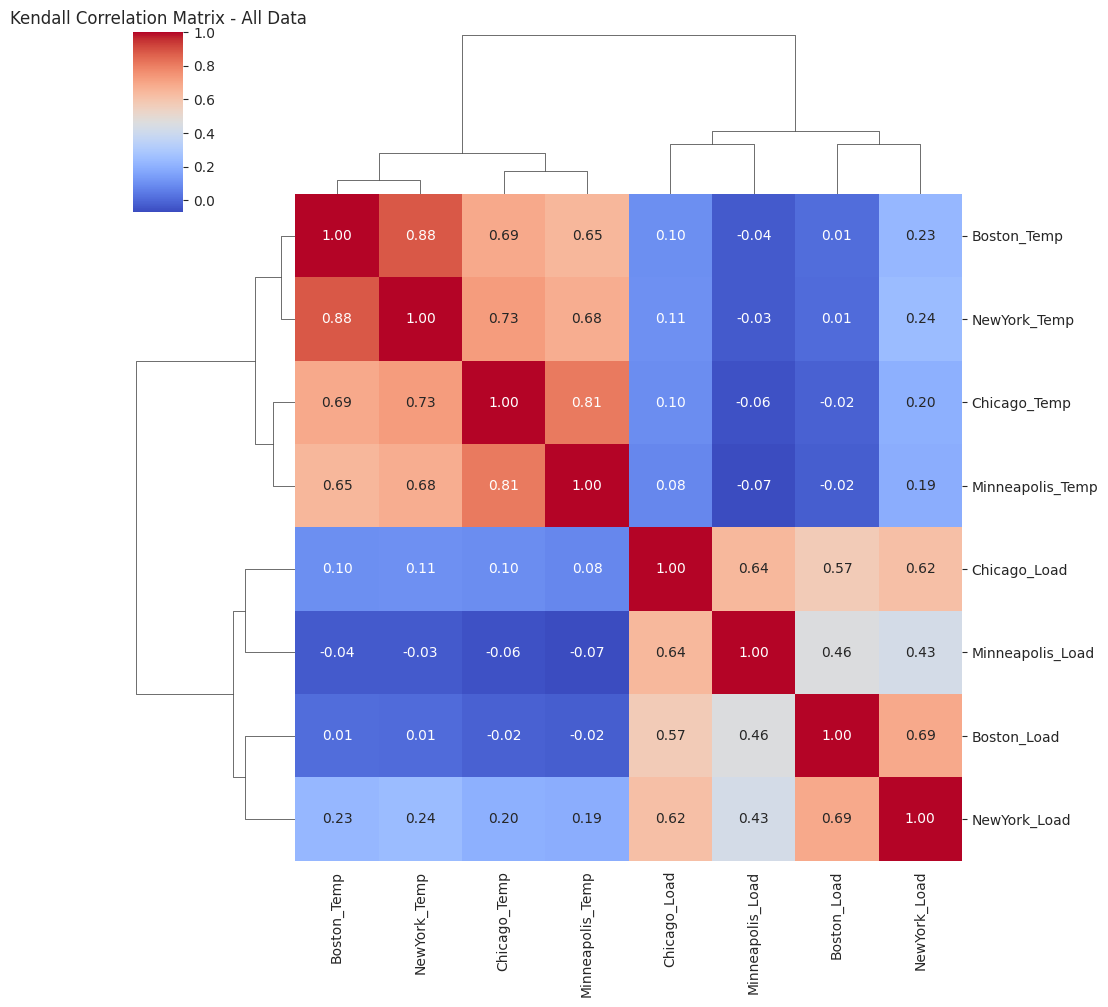

In [125]:
sns.clustermap(all_data_clean.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - All Data')
plt.show()

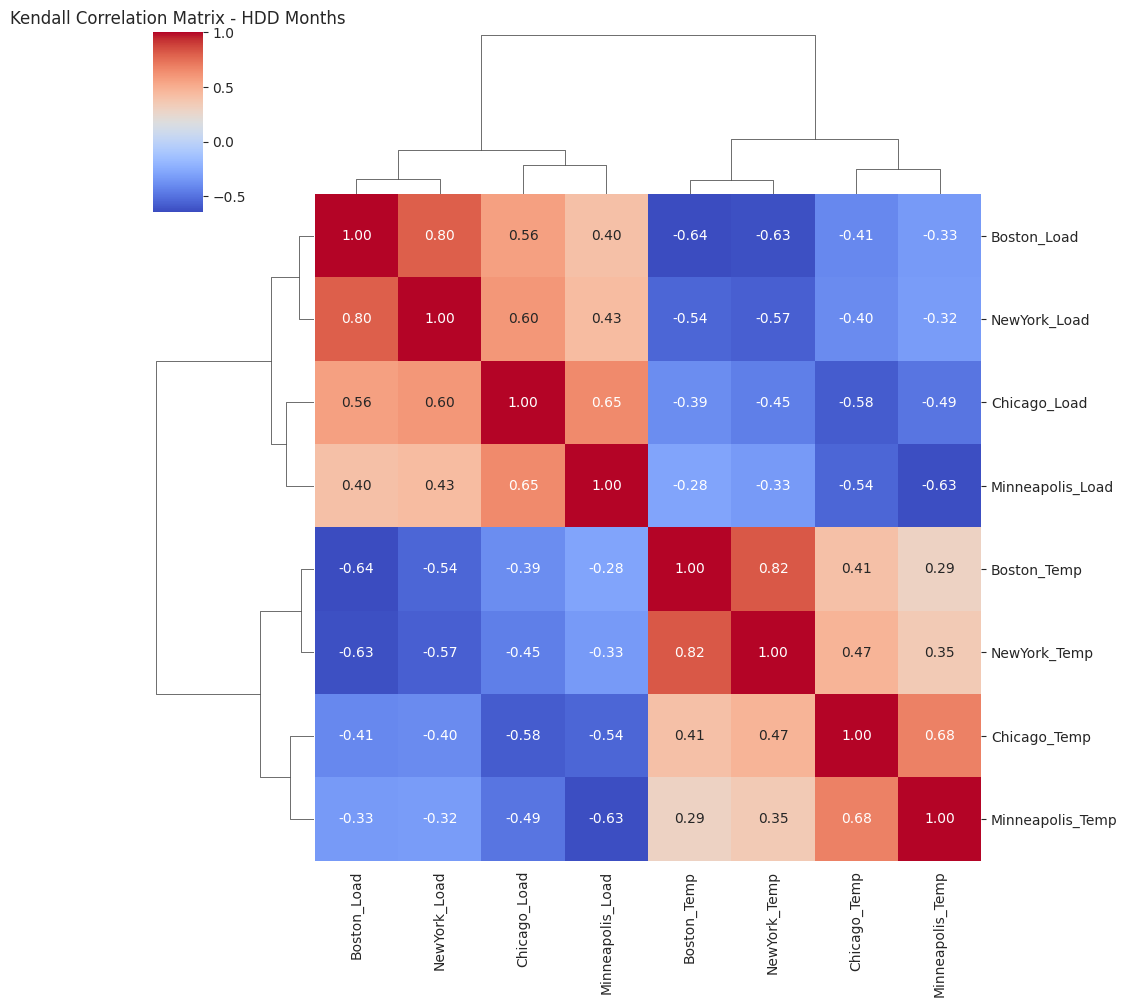

In [126]:
sns.clustermap(all_data_clean_hdd.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - HDD Months')
plt.show()

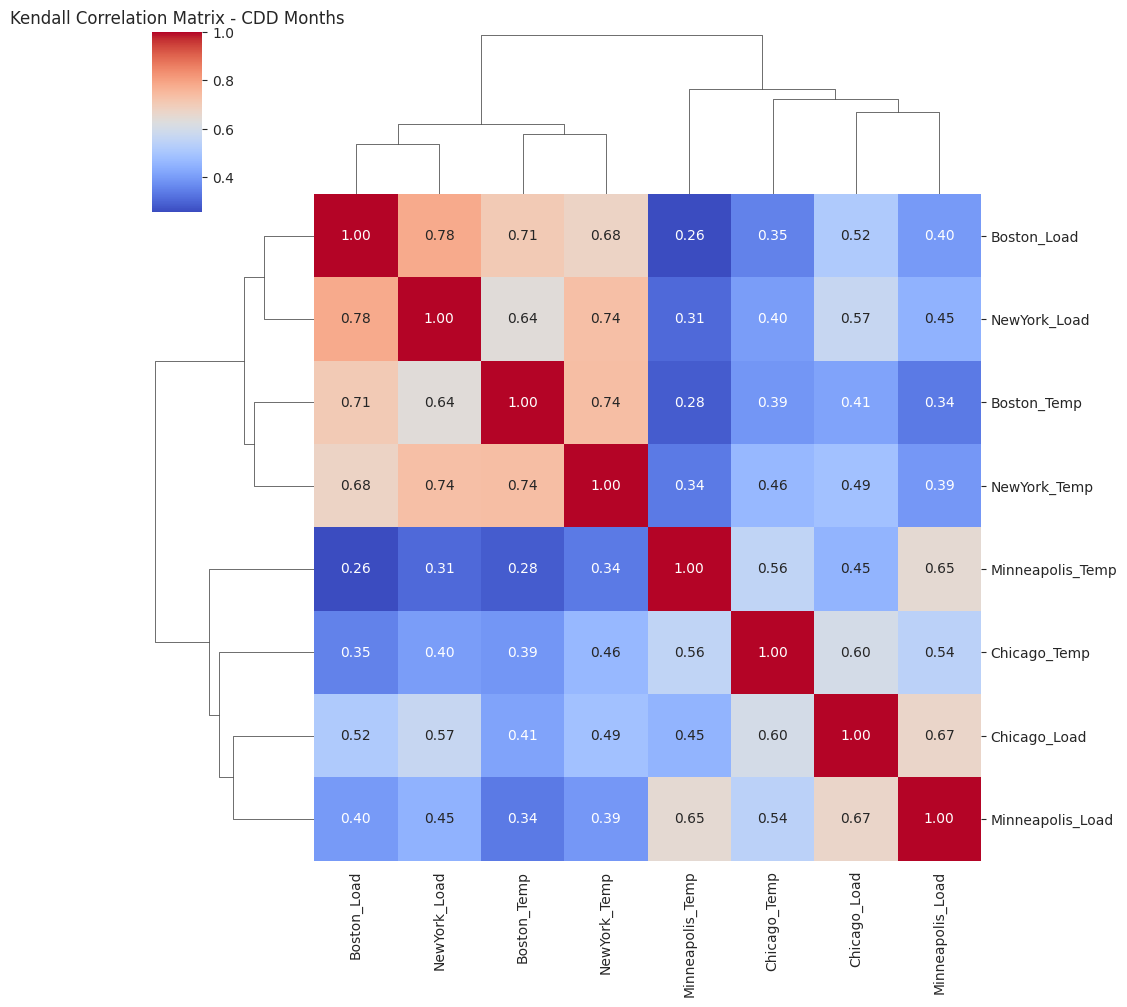

In [127]:
sns.clustermap(all_data_clean_cdd.corr(method='kendall'), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Kendall Correlation Matrix - CDD Months')
plt.show()

## 3.6. Residual Correlation Analysis

Extract residuals from the seasonal models (after removing seasonal patterns) and analyze their correlations.

In [128]:
# Extract residuals from pickle files
# Temperature residuals are in 'df_res' with city names as columns
temp_residuals = temp_data['df_res'].copy()
temp_residuals.columns = [f'{city}_Temp_Resid' for city in temp_residuals.columns]

# Load residuals are also in 'df_res' with city names as columns
load_residuals = load_data['df_res'].copy()
load_residuals.columns = [f'{city}_Load_Resid' for city in load_residuals.columns]

# Combine all residuals
all_residuals = pd.concat([temp_residuals, load_residuals], axis=1)
all_residuals_clean = all_residuals.dropna()

print(f"Residuals data shape: {all_residuals_clean.shape}")
print(f"Date range: {all_residuals_clean.index.min()} to {all_residuals_clean.index.max()}")
print(f"\nColumns: {all_residuals_clean.columns.tolist()}")
print(f"\nTemperature residuals preview:")
print(temp_residuals.head())
print(f"\nLoad residuals preview:")
print(load_residuals.head())

Residuals data shape: (3286, 8)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Columns: ['Chicago_Temp_Resid', 'NewYork_Temp_Resid', 'Minneapolis_Temp_Resid', 'Boston_Temp_Resid', 'Minneapolis_Load_Resid', 'Boston_Load_Resid', 'Chicago_Load_Resid', 'NewYork_Load_Resid']

Temperature residuals preview:
            Chicago_Temp_Resid  NewYork_Temp_Resid  Minneapolis_Temp_Resid  \
date                                                                         
2014-01-01           41.040282           49.593197               26.441416   
2014-01-02           -8.301969          -14.445957               -3.927996   
2014-01-03           -9.991465           -6.517986                8.191276   
2014-01-04           15.316474           -2.084672                5.494788   
2014-01-05          -13.812502           11.072880              -28.034009   

            Boston_Temp_Resid  
date                           
2014-01-01          43.874372  
2014-01-02         -20.320647  
2014-01-03   

In [129]:
# Split residuals by season
all_residuals_hdd = all_residuals_clean[all_residuals_clean.index.month.isin(MONTH_HDD)]
all_residuals_cdd = all_residuals_clean[all_residuals_clean.index.month.isin(MONTH_CDD)]

print(f"Residuals - HDD months: {all_residuals_hdd.shape[0]} days")
print(f"Residuals - CDD months: {all_residuals_cdd.shape[0]} days")
print(f"Residuals - All months: {all_residuals_clean.shape[0]} days")

Residuals - HDD months: 1360 days
Residuals - CDD months: 1377 days
Residuals - All months: 3286 days


<Figure size 1200x1000 with 0 Axes>

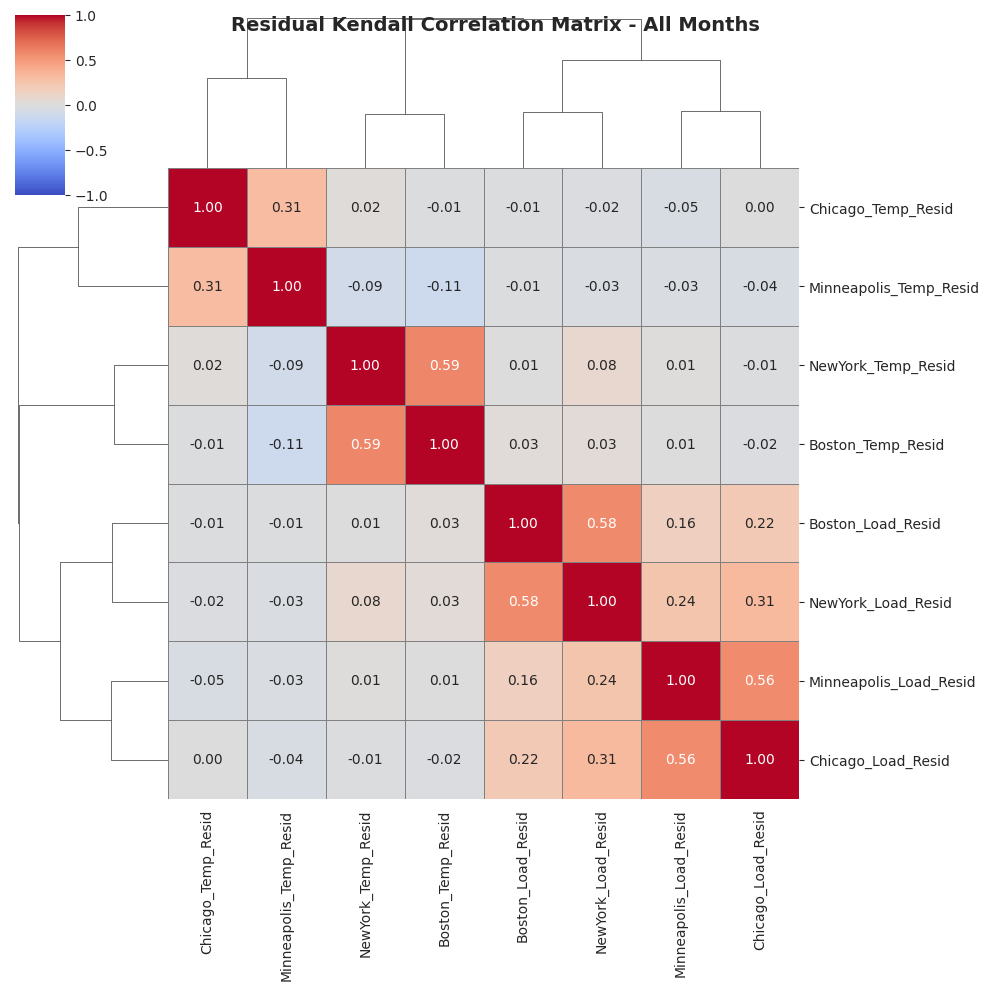

Residual Correlation Statistics (All Months):
       Chicago_Temp_Resid  NewYork_Temp_Resid  Minneapolis_Temp_Resid  \
count            8.000000            8.000000                8.000000   
mean             0.155846            0.201323                0.124711   
std              0.359886            0.385127                0.377574   
min             -0.045071           -0.091197               -0.114176   
25%             -0.015279            0.000845               -0.054506   
50%             -0.005181            0.018642               -0.026422   
75%              0.095631            0.210022                0.067419   
max              1.000000            1.000000                1.000000   

       Boston_Temp_Resid  Minneapolis_Load_Resid  Boston_Load_Resid  \
count           8.000000                8.000000           8.000000   
mean            0.188548                0.239907           0.245146   
std             0.392281                0.367842           0.363703   
min         

In [130]:
# Residual correlations - All months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_clean.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - All Months', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (All Months):")
print(all_residuals_clean.corr(method='kendall').describe())

<Figure size 1200x1000 with 0 Axes>

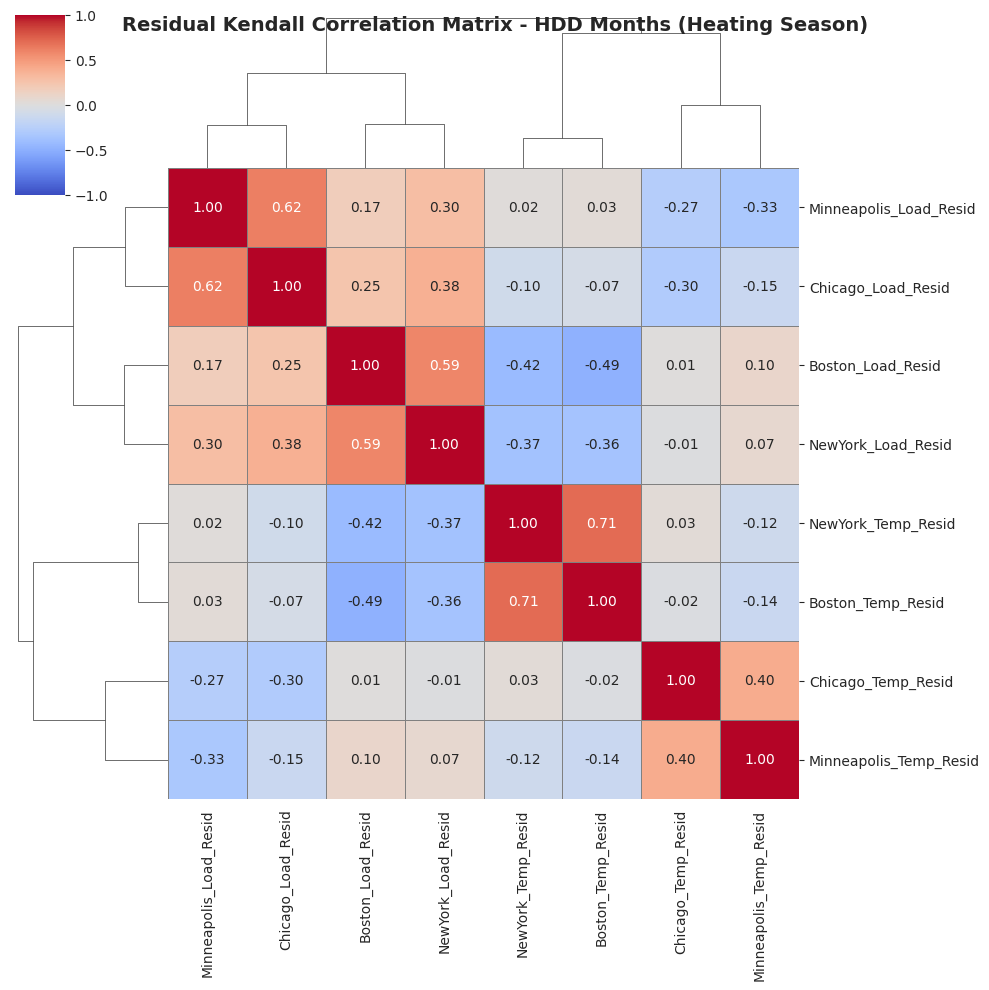

Residual Correlation Statistics (HDD Months):
       Chicago_Temp_Resid  NewYork_Temp_Resid  Minneapolis_Temp_Resid  \
count            8.000000            8.000000                8.000000   
mean             0.106868            0.093646                0.104776   
std              0.419424            0.503211                0.422638   
min             -0.296256           -0.424456               -0.325447   
25%             -0.079745           -0.181115               -0.143216   
50%             -0.000228           -0.037429               -0.022234   
75%              0.125386            0.201175                0.172057   
max              1.000000            1.000000                1.000000   

       Boston_Temp_Resid  Minneapolis_Load_Resid  Boston_Load_Resid  \
count           8.000000                8.000000           8.000000   
mean            0.083124                0.194375           0.150871   
std             0.512114                0.443996           0.490204   
min         

In [131]:
# Residual correlations - HDD months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_hdd.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - HDD Months (Heating Season)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_hdd.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (HDD Months):")
print(all_residuals_hdd.corr(method='kendall').describe())

<Figure size 1200x1000 with 0 Axes>

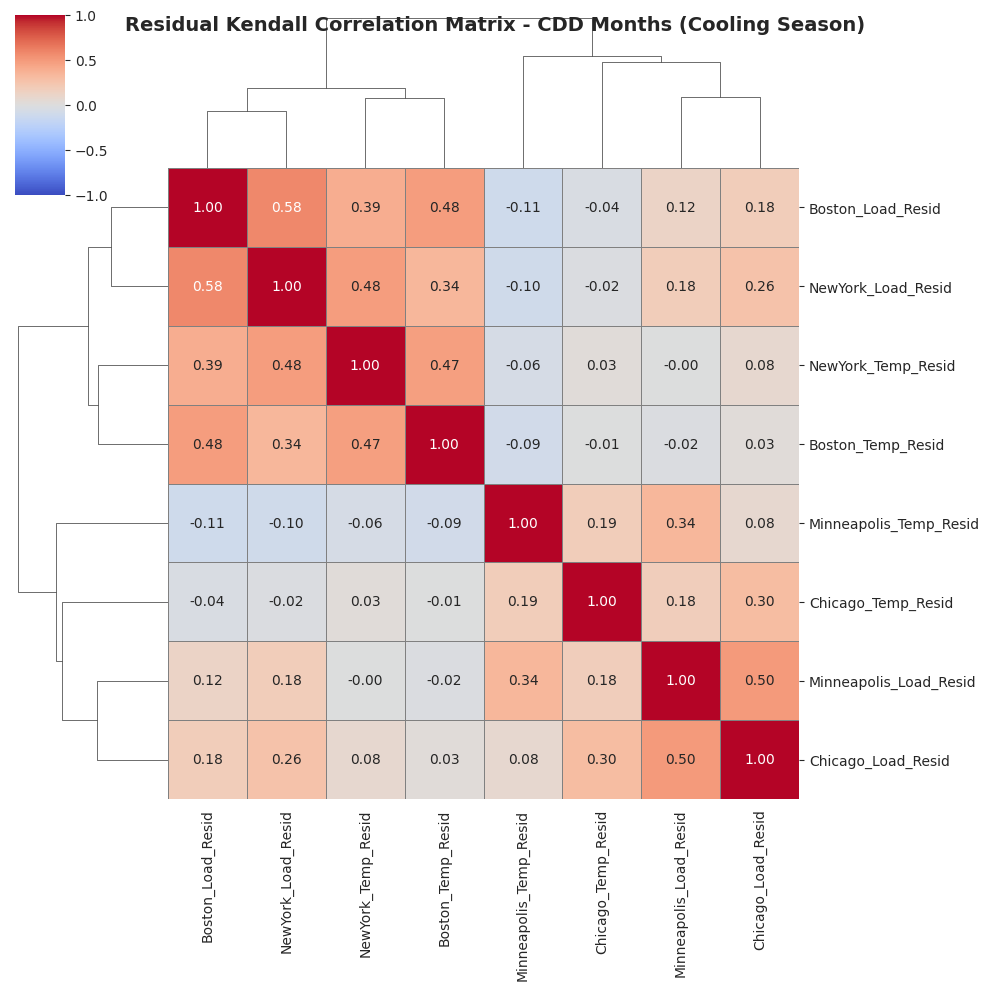

Residual Correlation Statistics (CDD Months):
       Chicago_Temp_Resid  NewYork_Temp_Resid  Minneapolis_Temp_Resid  \
count            8.000000            8.000000                8.000000   
mean             0.202905            0.297979                0.155705   
std              0.344671            0.359700                0.376857   
min             -0.039000           -0.060580               -0.107083   
25%             -0.010874            0.019327               -0.093600   
50%              0.101443            0.233357                0.008277   
75%              0.215089            0.472955                0.223831   
max              1.000000            1.000000                1.000000   

       Boston_Temp_Resid  Minneapolis_Load_Resid  Boston_Load_Resid  \
count           8.000000                8.000000           8.000000   
mean            0.274440                0.287219           0.327044   
std             0.373377                0.334775           0.364667   
min         

In [132]:
# Residual correlations - CDD months
fig = plt.figure(figsize=(12, 10))
sns.clustermap(all_residuals_cdd.corr(method='kendall'), annot=True, fmt=".2f", 
               cmap='coolwarm', center=0, vmin=-1, vmax=1,
               linewidths=0.5, linecolor='gray')
plt.suptitle('Residual Kendall Correlation Matrix - CDD Months (Cooling Season)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../data/images/residual_correlations_cdd.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Correlation Statistics (CDD Months):")
print(all_residuals_cdd.corr(method='kendall').describe())